<h1 align="center"><b>Homework Assignment 3 (100 points total)</b></h1>
<h3 align="center"><b>Assigned at the start of Module 5</b></h3>
<h3 align="center"><b>Due at the end of Module 7</b></h3><br>

# Q1 — Solving Einstein’s Riddle as a CSP

## 35 points total

**Einstein’s Riddle:**

There are **5 houses in a row**, each with a different color. Each house has an owner of a different nationality, a pet, a drink, and a cigar brand. The following clues apply:

1. The Brit lives in the red house.  
2. The Swede keeps dogs as pets.  
3. The Dane drinks tea.  
4. The green house is immediately to the left of the white house.  
5. The green house’s owner drinks coffee.  
6. The person who smokes Pall Mall rears birds.  
7. The owner of the yellow house smokes Dunhill.  
8. The man living in the center house drinks milk.  
9. The Norwegian lives in the first house.  
10. The man who smokes Blends lives next to the one who keeps cats.  
11. The man who keeps horses lives next to the man who smokes Dunhill.  
12. The man who smokes Blue Master drinks beer.  
13. The German smokes Prince.  
14. The Norwegian lives next to the blue house.  
15. The man who smokes Blends has a neighbor who drinks water.  

**Question**: Who owns the fish?

---

### [15 points] Part A – Coding (Implementation)

1. Model Einstein’s Riddle as a CSP using **OR-Tools CP-SAT**.  
   - **Variables**: House positions (1–5) for each attribute (color, nationality, pet, drink, cigar).  
   - **Domains**: {1, 2, 3, 4, 5}.  
   - **Constraints**: Encode the 15 given rules.  

2. Use the solver to find the unique solution.  

3. Print the assignments in a human-readable table.

---

### [20 points] Part B – Analysis (Explanation)

1. **Constraint Graph**:  
   Draw the constraint graph where nodes = attributes, edges = binary constraints (e.g., “Swede → Dogs”).  
   Classify each clue as **unary**, **binary**, or **positional**.

2. **Search Space Size**:  
   - Without constraints: how many permutations of 5 attributes across 5 houses?  
   - After adding AllDifferent + clue constraints: how much is pruned?  

3. **Constraint Propagation**:  
   Explain how AC-3 or forward checking would prune the domains before any search is done.  

4. **Complexity**:  
   Compare **pure backtracking** vs. **backtracking + constraint propagation** in terms of Big-O and expected runtime.  

5. **Reflection**:  
   Why does this puzzle have a *unique* solution, even though the search space is enormous?  
   How does that illustrate the power of CSP methods?


### Part A - Coding

In [18]:
from ortools.sat.python import cp_model
from IPython.display import HTML, display


def solve_einstein_riddle():
    model = cp_model.CpModel()

    houses = range(1, 6)

    colors = ["red", "green", "white", "yellow", "blue"]
    nationalities = ["Brit", "Swede", "Dane", "Norwegian", "German"]
    pets = ["dogs", "birds", "cats", "horses", "fish"]
    drinks = ["tea", "coffee", "milk", "beer", "water"]
    cigars = ["Pall Mall", "Dunhill", "Blends", "Blue Master", "Prince"]

    all_attributes = colors + nationalities + pets + drinks + cigars

    pos = {
        attr: model.NewIntVar(1, 5, attr.replace(" ", "_"))
        for attr in all_attributes
    }

    for category in [colors, nationalities, pets, drinks, cigars]:
        model.AddAllDifferent([pos[attr] for attr in category])

    def add_next_to(a, b):
        diff = model.NewIntVar(-4, 4, f"diff_{a}_{b}".replace(" ", "_"))
        abs_diff = model.NewIntVar(0, 4, f"abs_diff_{a}_{b}".replace(" ", "_"))
        model.Add(diff == pos[a] - pos[b])
        model.AddAbsEquality(abs_diff, diff)
        model.Add(abs_diff == 1)

    model.Add(pos["Brit"] == pos["red"])
    model.Add(pos["Swede"] == pos["dogs"])
    model.Add(pos["Dane"] == pos["tea"])
    model.Add(pos["green"] + 1 == pos["white"])
    model.Add(pos["green"] == pos["coffee"])
    model.Add(pos["Pall Mall"] == pos["birds"])
    model.Add(pos["yellow"] == pos["Dunhill"])
    model.Add(pos["milk"] == 3)
    model.Add(pos["Norwegian"] == 1)
    add_next_to("Blends", "cats")
    add_next_to("horses", "Dunhill")
    model.Add(pos["Blue Master"] == pos["beer"])
    model.Add(pos["German"] == pos["Prince"])
    add_next_to("Norwegian", "blue")
    add_next_to("Blends", "water")

    solver = cp_model.CpSolver()
    status = solver.Solve(model)

    if status not in [cp_model.OPTIMAL, cp_model.FEASIBLE]:
        display(HTML("<h3>No solution found.</h3>"))
        return model

    table = {
        i: {
            "House": i,
            "Color": None,
            "Nationality": None,
            "Pet": None,
            "Drink": None,
            "Cigar": None,
        }
        for i in houses
    }

    for color in colors:
        table[solver.Value(pos[color])]["Color"] = color

    for nationality in nationalities:
        table[solver.Value(pos[nationality])]["Nationality"] = nationality

    for pet in pets:
        table[solver.Value(pos[pet])]["Pet"] = pet

    for drink in drinks:
        table[solver.Value(pos[drink])]["Drink"] = drink

    for cigar in cigars:
        table[solver.Value(pos[cigar])]["Cigar"] = cigar

    fish_house = solver.Value(pos["fish"])
    fish_owner = None

    for nationality in nationalities:
        if solver.Value(pos[nationality]) == fish_house:
            fish_owner = nationality
            break

    html = """
    <p>Einstein's Riddle Solution:</p>
    <table style="border-collapse: collapse;">
        <thead>
            <tr>
                <th style="border: 1px solid black; padding: 6px;">House</th>
                <th style="border: 1px solid black; padding: 6px;">Color</th>
                <th style="border: 1px solid black; padding: 6px;">Nationality</th>
                <th style="border: 1px solid black; padding: 6px;">Pet</th>
                <th style="border: 1px solid black; padding: 6px;">Drink</th>
                <th style="border: 1px solid black; padding: 6px;">Cigar</th>
            </tr>
        </thead>
        <tbody>
    """

    for i in houses:
        row = table[i]
        html += f"""
            <tr>
                <td style="border: 1px solid black; padding: 6px;">{row['House']}</td>
                <td style="border: 1px solid black; padding: 6px;">{row['Color']}</td>
                <td style="border: 1px solid black; padding: 6px;">{row['Nationality']}</td>
                <td style="border: 1px solid black; padding: 6px;">{row['Pet']}</td>
                <td style="border: 1px solid black; padding: 6px;">{row['Drink']}</td>
                <td style="border: 1px solid black; padding: 6px;">{row['Cigar']}</td>
            </tr>
        """

    html += f"""
        </tbody>
    </table>

    <p>The owner of the fish is the {fish_owner}.</p>
    """

    display(HTML(html))
    return model

model = solve_einstein_riddle()

House,Color,Nationality,Pet,Drink,Cigar
1,yellow,Norwegian,cats,water,Dunhill
2,blue,Dane,horses,tea,Blends
3,red,Brit,birds,milk,Pall Mall
4,green,German,fish,coffee,Prince
5,white,Swede,dogs,beer,Blue Master


### Part B - Analysis
#### 1. Constraint Graph
In this CSP, each variable represents the house position of one attribute. Therefore, all the variables have domain $\{1, 2, 3, 4, 5\}$ where 1 is the leftmost house and 5 is the rightmost house. The variables are the attributes from each category in the following table:

| Colors | Nationalities | Pets   | Drinks | Cigars      |
|--------|---------------|--------|--------|-------------|
| red    | Brit          | dogs   | tea    | Pall Mall   |
| green  | Swede         | birds  | coffee | Dunhill     |
| white  | Dane          | cats   | milk   | Blends      |
| yellow | Norwegian     | horses | beer   | Blue Master |
| blue   | German        | fish   | water  | Prince      |

An edge exists between two variables if a clue directly constrains their positions. The constraint graph from the clues are as follows:


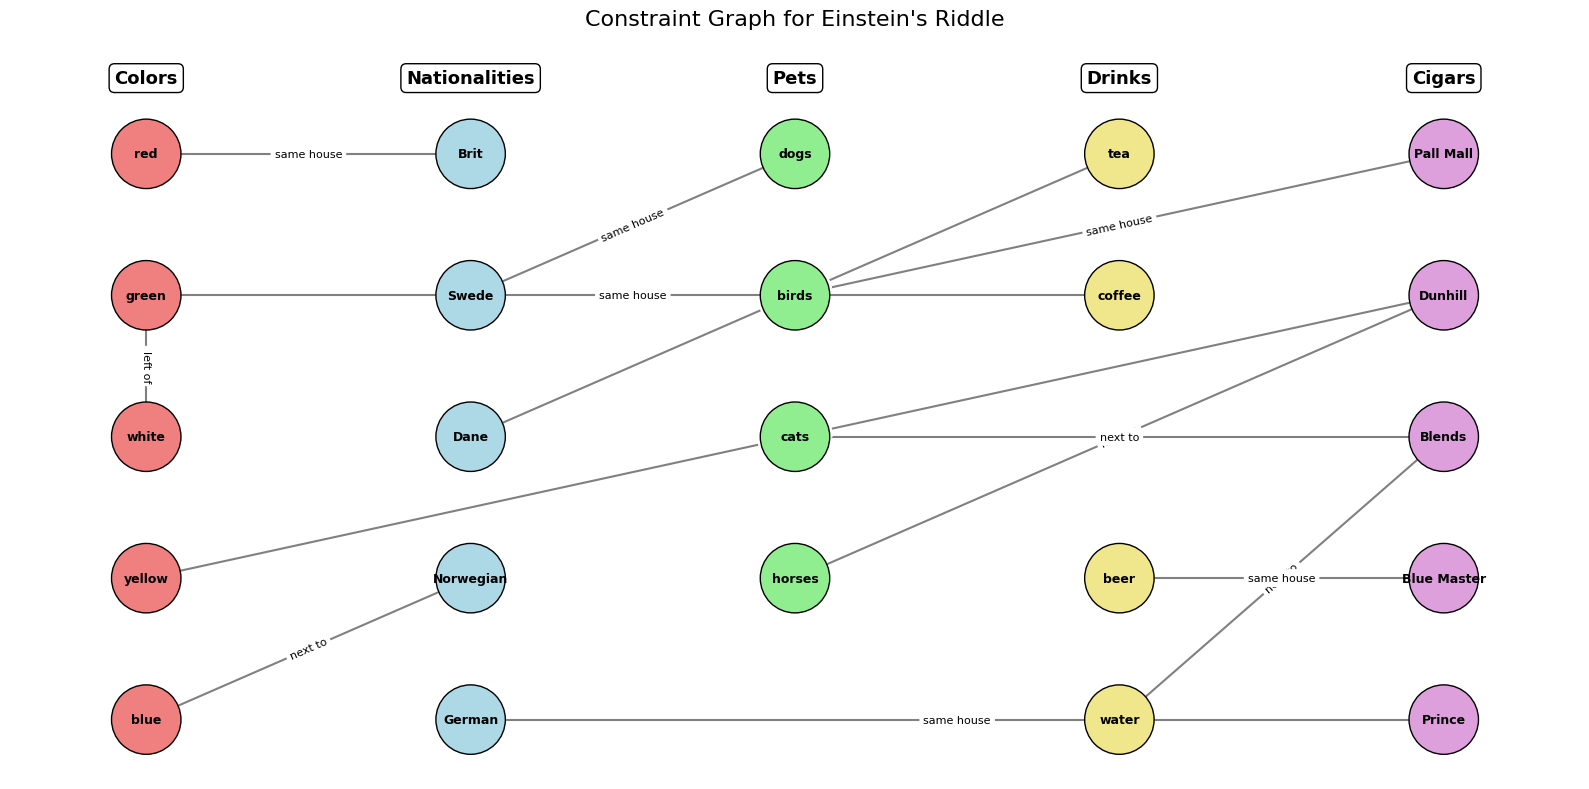

In [13]:
import networkx as nx
import matplotlib.pyplot as plt

# Categories
colors = ["red", "green", "white", "yellow", "blue"]
nationalities = ["Brit", "Swede", "Dane", "Norwegian", "German"]
pets = ["dogs", "birds", "cats", "horses", "fish"]
drinks = ["tea", "coffee", "milk", "beer", "water"]
cigars = ["Pall Mall", "Dunhill", "Blends", "Blue Master", "Prince"]

# Binary clue constraints
edges = [
    ("Brit", "red", "same house"),
    ("Swede", "dogs", "same house"),
    ("Dane", "tea", "same house"),
    ("green", "white", "left of"),
    ("green", "coffee", "same house"),
    ("Pall Mall", "birds", "same house"),
    ("yellow", "Dunhill", "same house"),
    ("Blends", "cats", "next to"),
    ("horses", "Dunhill", "next to"),
    ("Blue Master", "beer", "same house"),
    ("German", "Prince", "same house"),
    ("Norwegian", "blue", "next to"),
    ("Blends", "water", "next to"),
]

G = nx.Graph()

for u, v, label in edges:
    G.add_edge(u, v, label=label)

# Manual clustered layout
categories = {
    "Colors": colors,
    "Nationalities": nationalities,
    "Pets": pets,
    "Drinks": drinks,
    "Cigars": cigars,
}

x_positions = {
    "Colors": 0,
    "Nationalities": 3,
    "Pets": 6,
    "Drinks": 9,
    "Cigars": 12,
}

pos = {}

for category_name, nodes in categories.items():
    x = x_positions[category_name]
    for i, node in enumerate(nodes):
        # Negative i spaces nodes vertically
        pos[node] = (x, -i * 2)

# Node colors by category
node_color_map = {
    "Colors": "lightcoral",
    "Nationalities": "lightblue",
    "Pets": "lightgreen",
    "Drinks": "khaki",
    "Cigars": "plum",
}

node_colors = []

for node in G.nodes():
    for category_name, nodes in categories.items():
        if node in nodes:
            node_colors.append(node_color_map[category_name])
            break

plt.figure(figsize=(16, 8))

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=2500,
    edgecolors="black"
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=9,
    font_weight="bold"
)

nx.draw_networkx_edges(
    G,
    pos,
    edge_color="gray",
    width=1.5
)

edge_labels = nx.get_edge_attributes(G, "label")

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=8,
    label_pos=0.5
)

# Add category labels above each cluster
for category_name, x in x_positions.items():
    plt.text(
        x,
        1,
        category_name,
        fontsize=13,
        fontweight="bold",
        ha="center",
        bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3")
    )

plt.title("Constraint Graph for Einstein's Riddle", fontsize=16, pad=50)
plt.axis("off")
plt.tight_layout()
plt.show()

In addition to the clue edges, each category has an `AllDifferent` constraint. For example:
`AllDifferent(red, green, white, yellow, blue)`
means no two colors can occupy the same house. Similarly, we have:

```
AllDifferent(Brit, Swede, Dane, Norwegian, German)
AllDifferent(dogs, birds, cats, horses, fish)
AllDifferent(tea, coffee, milk, beer, water)
AllDifferent(Pall Mall, Dunhill, Blends, Blue Master, Prince)
```

The categories in the graph above implicitly have this constraint. This constraint is not drawn as edges to avoid clutter.

The clue classifications are as follows:

| No. | Clue                                                           | Type                         |
|----:|----------------------------------------------------------------|------------------------------|
|   1 | The Brit lives in the red house.                               | Binary equality              |
|   2 | The Swede keeps dogs.                                          | Binary equality              |
|   3 | The Dane drinks tea.                                           | Binary equality              |
|   4 | The green house is immediately to the left of the white house. | Positional binary constraint |
|   5 | The green house’s owner drinks coffee.                         | Binary equality              |
|   6 | Pall Mall smoker rears birds.                                  | Binary equality              |
|   7 | Yellow house owner smokes Dunhill.                             | Binary equality              |
|   8 | Center house drinks milk.                                      | Unary positional constraint  |
|   9 | Norwegian lives in the first house.                            | Unary positional constraint  |
|  10 | Blends smoker lives next to cats owner.                        | Positional binary constraint |
|  11 | Horses are next to Dunhill smoker.                             | Positional binary constraint |
|  12 | Blue Master smoker drinks beer.                                | Binary equality              |
|  13 | German smokes Prince.                                          | Binary equality              |
|  14 | Norwegian lives next to blue house.                            | Positional binary constraint |
|  15 | Blends smoker has neighbor who drinks water.                   | Positional binary constraint |

#### 2. Search Space Size
There are 5 categories - Color, Nationality, Pet, Drink, and Cigar. Each category contains 5 attributes that must be assigned to 5 houses. If we assume each category is a permutation of 5 distinct attributes across 5 houses, then each category has $5! = 120$ possible assignments. For 5 independent categories, there are $120^5 = 24,883,200,000$ possible assignments. A naive brute force solution would check all $24,883,200,000$ possibilities, which would take an insane amount of time.

However, if the solution is found optimally, after applying all the constraints, the puzzle has exactly $1$ valid solution, as demonstrated below:


In [16]:
from ortools.sat.python import cp_model

class SolutionCounter(cp_model.CpSolverSolutionCallback):
    def __init__(self):
        cp_model.CpSolverSolutionCallback.__init__(self)
        self.solution_count = 0

    def OnSolutionCallback(self):
        self.solution_count += 1

solver = cp_model.CpSolver()
counter = SolutionCounter()
solver.SearchForAllSolutions(model, counter)

print("Number of valid solutions:", counter.solution_count)

Number of valid solutions: 1


#### 3. Constraint Propagation
Before performing search, constraint propagation can reduce the possible domains of variables by eliminating values that cannot participate in any valid solution.

In Einstein’s Riddle, each item can be modeled as a variable whose domain is the set of house positions:

$$D(x) = \{1,2,3,4,5\}$$

For example:

$$red, green, Brit, tea, dogs, \ldots \in \{1,2,3,4,5\}$$

A constraint such as $Brit = red$ means that the Brit and the red house must have the same position. A positional constraint such as $green = white - 1$ means that the $green$ house must be immediately to the left of the $white$ house.

###### Unary Constraints
Unary constraints prune domains immediately. For example, $milk = 3$ because the center house drinks milk. Also, $Norwegian = 1$ because the Norwegian lives in the first house. So the domains become:

$$D(milk) = \{3\}$$
$$D(Norwegian) = \{1\}$$

These values can then be removed from the domains of other variables in the same `AllDifferent` group. For example, since $Norwegian$ is a nationality, no other nationality can be in house 1, so:

$$D(Brit), D(Swede), D(Dane), D(German) \neq 1$$

Similarly, since $milk$ is a drink, no other drink can be in house 3, so:

$$D(tea), D(coffee), D(beer), D(water) \neq 3$$

###### AC-3 Arc Consistency
AC-3 enforces consistency between pairs of variables. For each binary constraint, it checks whether every value in one variable’s domain has at least one compatible value in the other variable’s domain. If not, that value is removed. For example, the clue $green = white - 1$ requires the $green$ house to be immediately left of the $white$ house. Initially:

$$D(green) = D(white) = \{1,2,3,4,5\}$$

AC-3 removes impossible positions:

- $green$ cannot be 5, because there is no house 6 for $white$.
- $white$ cannot be 1, because there is no house 0 for $green$.

So:

$$D(green) = \{1,2,3,4\}$$

$$D(white) = \{2,3,4,5\}$$

The clue that $Norwegian$ is next to $blue$ combined with the constraint $Norwegian = 1$ forces $blue = 2$ because the only neighbor of house 1 is house 2. This then propagates through the `AllDifferent` constraint for colors, so no other color can be in house 2.

###### Forward Checking

Forward checking performs pruning whenever a variable is assigned. For example, once we assign $Norwegian = 1$, forward checking removes house 1 from the domains of the other nationalities. Then, using the constraint that $Norwegian$ is next to $blue$, it restricts $blue$ to house 2.

Similarly, once we assign $milk$ to house 3, forward checking removes house 3 from the other drink domains.

If later we assign $green$ to house 4, then forward checking immediately forces $white$ to house 5 because the $white$ house must be immediately to the right of the $green$ house.

###### Effect on the Search Space

Constraint propagation greatly reduces the number of possibilities before any brute-force search is attempted. Instead of blindly checking all $24,883,200,000$ possible assignments, the solver eliminates inconsistent values early. This pruning makes the remaining search space much smaller and allows backtracking or CP-SAT solving to find the solution efficiently.

#### 4. Complexity
Let $n$ be the number of variables and $d$ be the maximum domain size. Here, $n = 25$ and $d = 5$.

###### Pure backtracking
Pure backtracking tries assignments recursively and checks constraints after assignments. This problem has a permutation structure, because within each category, the five attributes must be assigned to the five houses exactly once. In the worst case, pure backtracking still searches every possible assignment, even if infeasible. So, the time complexity is $O(d!^n)$.

###### Backtracking with Constraint Propagation
Backtracking with constraint propagation still has a time complexity of $O(d!^n)$, because in the worst case, it can still search every possible assignment. However, the practical runtime is much better. Constraint propagation, such as forward checking or AC-3, prunes inconsistent values from variable domains before and during search. This reduces the effective branching factor from $d!$ to a smaller value $b$. So, the practical runtime behaves more like $O(b^n)$ where $b < d!$.

#### 5. Reflection
The puzzle has a unique solution because the constraints interact very tightly. Some clues fix absolute positions while others force adjacency. Also, some clues tie attributes together in the same house. Individually, each clue eliminates only part of the search space. But together, they interact to eliminate almost every possible assignment.

For example, the constraint that $Norwegian$ is in house 1 combined with the constraint that $Norwegian$ is next to $blue$ implies that $blue$ is in house 2. Then, the `AllDifferent` constraints restrict the other colors. The center house drinks $milk$, so the $green$ house cannot be the center because the $green$ house drinks $coffee$. Since $green$ must be immediately left of $white$, this greatly restricts the possible locations of $green$ and $white$.

This cascading effect is what makes CSP methods powerful. A CSP solver does not blindly enumerate all possible assignments. Instead, it reasons locally using constraints, prunes invalid partial assignments early, and quickly converges to the only globally consistent assignment. Einstein’s Riddle is a good example of how a seemingly enormous search problem can become easy when represented with the right variables, constraints, and propagation methods.

# Q2 — Inference in Bayesian Networks

## 30 points total

Consider the following Bayesian network representing a simplified medical diagnosis scenario:

- Flu ($F$): binary variable (Yes/No)
- Cold ($C$): binary variable (Yes/No)
- Fever ($Fe$): depends on Flu and Cold
- Cough ($Co$): depends on Cold
- Fatigue ($Fa$): depends on Flu

**Conditional Probability Tables (CPTs)**
- Prior probabilities:
    - $P$($F$ = Yes) = 0.05, $P$($F$ = No) = 0.95
    - $P$($C$ = Yes) = 0.10, $P$($C$ = No) = 0.90
- Conditional distributions:
    - $P$($Fe$ = Yes | $F$, $C$):
        - Flu = Yes, Cold = Yes → 0.90
        - Flu = Yes, Cold = No → 0.80
        - Flu = No, Cold = Yes → 0.70
        - Flu = No, Cold = No → 0.05
    - $P$($Co$ = Yes | Cold):
        - Cold = Yes → 0.80
        - Cold = No → 0.10
    - $P$($Fa$ = Yes | Flu):
        - Flu = Yes → 0.75
        - Flu = No → 0.20


### [10 points] Exact Inference

Compute the posterior probability that a patient has Flu, given that they present with Fever = Yes and Cough = Yes.

$$P(F = \text{Yes} | Fe = \text{Yes}, Co = \text{Yes})$$

Show the numerator, denominator/normalization step, and final posterior.

### [10 points] Approximate Inference
Outline how you would estimate the same posterior using Likelihood Weighting. Describe:
- How you would generate samples
- How evidence is handled
- How weights are assigned
- How the posterior is approximated from weighted samples

### [10 points] Scalability and Trade-offs
Explain why exact inference may become expensive in larger Bayesian networks. Compare exact inference and likelihood weighting in terms of accuracy, computational cost, scalability, and limitations.

### Exact Inference Answer
Let:

$$F_y \equiv F=\text{Yes}, \quad F_n \equiv F=\text{No}$$
$$C_y \equiv C=\text{Yes}, \quad C_n \equiv C=\text{No}$$
$$Fe_y \equiv Fe=\text{Yes}, \quad Co_y \equiv Co=\text{Yes}$$

We want:

$$P(F_y \mid Fe_y, Co_y)$$

Using Bayes’ rule:
$$P(F_y \mid Fe_y, Co_y)
=
\frac{P(F_y, Fe_y, Co_y)}
{P(Fe_y, Co_y)}$$

#### Numerator
The un-normalized probability is:

$$\begin{split}
P(F_y, Fe_y, Co_y)
&= P(F_y)\sum_C P(C)P(Fe_y\mid F_y,C)P(Co_y\mid C) \\
&= P(F_y)\Big[
P(C_y)P(Fe_y\mid F_y,C_y)P(Co_y\mid C_y) \\
&\qquad + P(C_n)P(Fe_y\mid F_y,C_n)P(Co_y\mid C_n)
\Big] \\
&= 0.05\Big[
(0.10)(0.90)(0.80) \\
&\qquad + (0.90)(0.80)(0.10)
\Big] \\
&= 0.05[0.072 + 0.072] \\
&= 0.05(0.144) \\
&= 0.0072
\end{split}$$

#### Denominator / Normalization
The denominator is:
$$P(Fe_y, Co_y)
=
P(F_y, Fe_y, Co_y)
+
P(F_n, Fe_y, Co_y)$$
We already have:
$$P(F_y, Fe_y, Co_y)=0.0072$$
Now compute the unnormalized probability for $F_n$:
$$\begin{split}
P(F_n, Fe_y, Co_y)
&= P(F_n)\sum_C P(C)P(Fe_y\mid F_n,C)P(Co_y\mid C) \\
&= P(F_n)\Big[
P(C_y)P(Fe_y\mid F_n,C_y)P(Co_y\mid C_y) \\
&\qquad + P(C_n)P(Fe_y\mid F_n,C_n)P(Co_y\mid C_n)
\Big] \\
&= 0.95\Big[
(0.10)(0.70)(0.80) \\
&\qquad + (0.90)(0.05)(0.10)
\Big] \\
&= 0.95[0.056 + 0.0045] \\
&= 0.95(0.0605) \\
&= 0.057475
\end{split}$$
Therefore:
$$\begin{split}
P(Fe_y, Co_y)
&= P(F_y, Fe_y, Co_y) + P(F_n, Fe_y, Co_y) \\
&= 0.0072 + 0.057475 \\
&= 0.064675
\end{split}$$

Final Posterior
$$\begin{split}
P(F_y \mid Fe_y, Co_y)
&= \frac{P(F_y, Fe_y, Co_y)}
{P(Fe_y, Co_y)} \\
&= \frac{0.0072}{0.064675} \\
&\approx 0.1113
\end{split}$$

So the posterior probability that the patient has Flu, given Fever and Cough, is approximately $11.13\%$.

### Approximate Inference Answer
We want to estimate $P(F_y \mid Fe_y, Co_y)$ where $Fe_y, Co_y$ is the evidence is. In Likelihood Weighting, samples that disagree with the evidence are not rejected. Instead, evidence variables are clamped to their observed values, and samples are assigned weights based on how likely that evidence is given the sampled variables.

Likelihood Weighting is often more efficient than rejection sampling because it does not discard samples. As a result, every generated sample contributes to the final posterior estimate, although samples that make the evidence unlikely contribute less due to having smaller weights. This can allow a reasonable estimate with fewer generated samples, especially when the evidence is rare.

#### Generating Samples
The Bayesian network variables are sampled in topological order - $F, C, Fe, Co, Fa$. For each sample:

1. Sample $F$ from its prior: $P(F_y)=0.05, \quad P(F_n)=0.95$
2. Sample $C$ from its prior: $P(C_y)=0.10, \quad P(C_n)=0.90$
3. Since $Fe$ is evidence, set: $Fe = Fe_y$
4. Since $Co$ is evidence, set: $Co = Co_y$

Note that $Fa$ can be disregarded, as it is not part of the query or the evidence.

#### Handle evidence
The evidence variables are $Fe_y, Co_y$. In Likelihood Weighting, evidence variables are not sampled. They are clamped to their observed values. So for every sample, $Fe = Fe_y$ and $Co = Co_y$. Since the evidence is a set assumption, an adjustment needs to be made to ensure a fair representation of each sample. Instead of rejecting inconsistent samples, the sample probability is multiplied by the probability of the evidence given its parents.

#### Assign Weights
The weights $w$ represent how likely $Fe_y$ and $Co_y$ occur given what was sampled. So:

$$w = P(Fe_y, Co_y \mid F, C)$$

Since $Fe_y$ and $Co_y$ are independent to each other:

$$w = P(Fe_y \mid F, C)P(Co_y \mid C)$$
$$w = P(Fe_y \mid F, C)P(Co_y \mid C)$$

#### Calculate Posterior
Since $w$ represents how likely the evidence is to occur, the following equation can be used to calculate the posterior:

$$\hat{P}(F_y \mid Fe_y, Co_y) = \frac{\text{total $w$ of samples with } F_y}
{\text{total $w$ of all samples}}$$
$$\hat{P}(F_y \mid Fe_y, Co_y) = \frac{\sum_{i} w_i I(F_i = F_y)}{\sum_{i} w_i}$$

Where $i$ represents a sample, $w_i$ is the weight of that sample, $F_i$ represents whether that sample has $F = \text{Yes}$ or $F = \text{no}$, and $I(\cdot)$ is the indicator function.

#### Scalability and Trade-offs
Exact inference can become expensive in larger Bayesian networks because it often requires summing over many hidden variables. As the number of variables grows, the number of possible assignments can grow exponentially, especially when variables have many parents or the network has high treewidth. Exact methods give the true posterior probability, but they may require large amounts of time and memory for complex networks.

Likelihood Weighting is more scalable because it estimates the posterior using weighted samples instead of enumerating all possible hidden-variable assignments. It is usually cheaper per sample and can be stopped early if an approximate answer is acceptable. However, it is approximate rather than exact, so its accuracy depends on the number and quality of samples. It is often more efficient than rejection sampling because it does not discard evidence-inconsistent samples, but it can still perform poorly when the evidence is very unlikely or far downstream, since many samples may receive very small weights. Thus, exact inference is more accurate but less scalable, while likelihood weighting is more scalable but introduces sampling error.

# Q3 — Principal Component Analysis on MNIST  

## 35 points total

In this problem, you will implement **Principal Component Analysis (PCA)** from scratch using the MNIST dataset. You must not use the built-in PCA functions in scikit-learn. Instead, you will write the steps yourself using NumPy. Use at least **1000 samples** and ensure the data is class-balanced.  

You may download the dataset from either of the following sources:  
- Import directly into your notebook
- Alternative dataset links: [GTDLBench](https://git-disl.github.io/GTDLBench/datasets/mnist_datasets/), [Kaggle](https://www.kaggle.com/datasets/hojjatk/mnist-dataset), [Hugging Face](https://huggingface.co/datasets/ylecun/mnist)

---

### [15 points] Part A – Coding (Implementation)  

### Data Preparation  
- Load MNIST 
- Select at least **1000 balanced samples**.  
- Flatten images into vectors and **standardize the data**.  

### PCA from Scratch  
- Compute the **covariance matrix**.  
- Find **eigenvalues** and **eigenvectors**.  
- Sort eigenvalues and project the data into the new space.  

### Variance Explained  
- Plot the **explained variance** (scree plot).  
- Determine how many principal components to retain.  

---

### [20 points] Part B – Analysis (Explanation)  

### Component Selection  
- Justify your choice of how many components to keep.  
- Discuss trade-offs between dimensionality reduction and information retention.  

### Visualization  
- Create at least **five distinct 2D scatter plots** of the data projected onto different pairs of principal components (e.g., PC1 vs. PC2, PC2 vs. PC3, etc.), coloring points by digit class.  
- Comment on what these plots reveal about **class separability** and **structure** in the data.  

### Interpretation  
- Explain why each step of PCA matters (**covariance, eigenvalues, variance explained**).  
- Discuss one **real-world application** where PCA would be useful.  


### Part A Answer
The following PCA steps were performed manually using NumPy:

1. Load MNIST.
2. Select a balanced subset of at least 1000 samples.
3. Flartten and standardize the data.
4. Compute the covariance matrix.
5. Compute eigenvalues and eigenvectors.
6. Sort the eigenvalues and eigenvectors.
7. Project the data into the principal component space.
8. Plot explained variance.
9. Visualize the data using different pairs of principal components.
10. Interpret the results.

Original data shape: (70000, 784)
Original labels shape: (70000,)
Balanced data shape: (1000, 784)
Balanced labels shape: (1000,)
Class counts:
{np.int64(0): np.int64(100), np.int64(1): np.int64(100), np.int64(2): np.int64(100), np.int64(3): np.int64(100), np.int64(4): np.int64(100), np.int64(5): np.int64(100), np.int64(6): np.int64(100), np.int64(7): np.int64(100), np.int64(8): np.int64(100), np.int64(9): np.int64(100)}


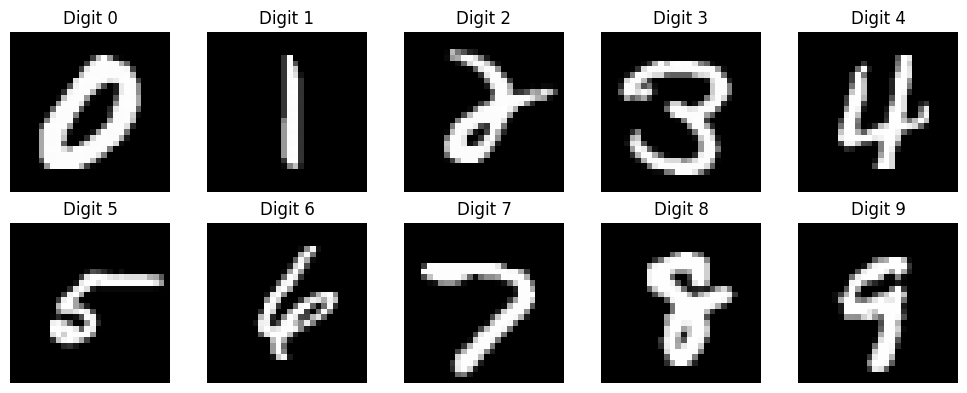

Standardized data shape: (1000, 784)
Overall mean after standardization: -8.700523295021634e-19
Overall standard deviation after standardization: 0.8864052604279182
Covariance matrix shape: (784, 784)
Eigenvalues shape: (784,)
Eigenvectors shape: (784, 784)
Top 10 eigenvalues:
[39.94131614 29.45769861 27.05279067 21.87188349 17.99258827 15.68704241
 14.90187864 13.39453023 11.444401   10.59457589]
PCA projected data shape: (1000, 784)
First 10 explained variance ratios:
[0.06477496 0.04777312 0.04387295 0.0354708  0.02917954 0.02544051
 0.02416717 0.02172262 0.01855999 0.01718179]
First 10 cumulative variance values:
[0.06477496 0.11254808 0.15642103 0.19189183 0.22107137 0.24651188
 0.27067905 0.29240167 0.31096166 0.32814345]


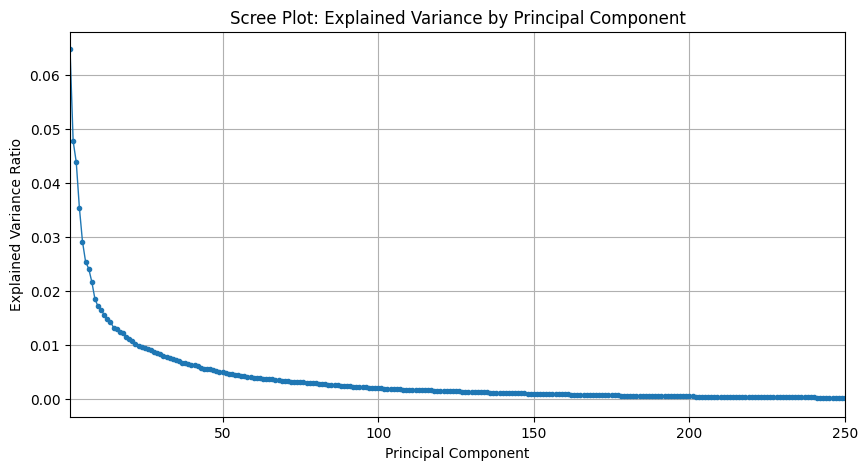

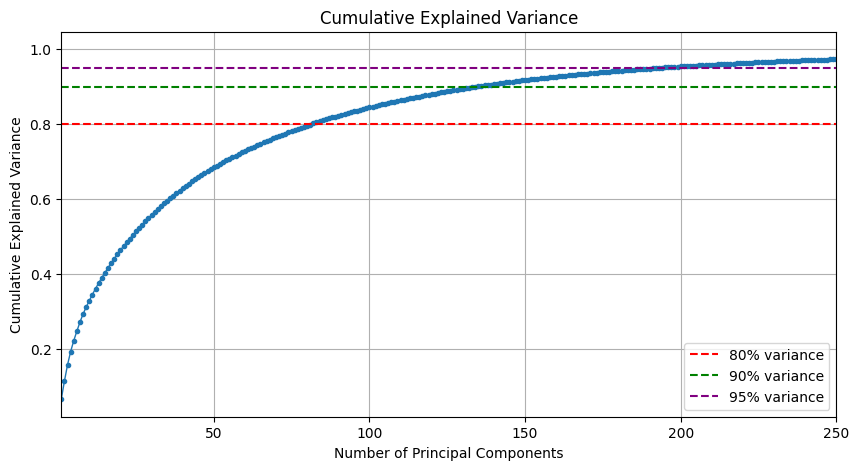

Number of components needed for 80% variance: 82
Number of components needed for 90% variance: 135
Number of components needed for 95% variance: 193


In [20]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml

# Load MNIST Dataset
# Each image is 24x24 pixels represented as a 784 dimensional vector
mnist = fetch_openml("mnist_784", version=1, as_frame=False)

X = mnist.data
y = mnist.target.astype(int)

print("Original data shape:", X.shape)
print("Original labels shape:", y.shape)

# Select 1000 Balanced Samples
np.random.seed(42)

samples_per_class = 100
selected_indices = []

for digit in range(10):
    digit_indices = np.where(y == digit)[0]
    chosen_indices = np.random.choice(
        digit_indices,
        size=samples_per_class,
        replace=False
    )
    selected_indices.extend(chosen_indices)

selected_indices = np.array(selected_indices)

X_balanced = X[selected_indices]
y_balanced = y[selected_indices]

print("Balanced data shape:", X_balanced.shape)
print("Balanced labels shape:", y_balanced.shape)

unique, counts = np.unique(y_balanced, return_counts=True)
print("Class counts:")
print(dict(zip(unique, counts)))

# Display Example Images
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for digit in range(10):
    ax = axes[digit // 5, digit % 5]
    idx = np.where(y_balanced == digit)[0][0]
    ax.imshow(X_balanced[idx].reshape(28, 28), cmap="gray")
    ax.set_title(f"Digit {digit}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# Standardize the data
mean = np.mean(X_balanced, axis=0)
std = np.std(X_balanced, axis=0)

# Avoid division by zero for pixels with zero variance
std[std == 0] = 1

X_standardized = (X_balanced - mean) / std

print("Standardized data shape:", X_standardized.shape)
print("Overall mean after standardization:", np.mean(X_standardized))
print("Overall standard deviation after standardization:", np.std(X_standardized))

# Compute the Covariance Matrix
cov_matrix = np.cov(X_standardized, rowvar=False)

print("Covariance matrix shape:", cov_matrix.shape)

# Compute Eigenvalues and Eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

print("Eigenvalues shape:", eigenvalues.shape)
print("Eigenvectors shape:", eigenvectors.shape)

# Sort Eigenvalues and Eigenvectors
sorted_indices = np.argsort(eigenvalues)[::-1]

eigenvalues_sorted = eigenvalues[sorted_indices]
eigenvectors_sorted = eigenvectors[:, sorted_indices]

print("Top 10 eigenvalues:")
print(eigenvalues_sorted[:10])

# Project the Data into PCA Space
X_pca = X_standardized @ eigenvectors_sorted

print("PCA projected data shape:", X_pca.shape)

# Explained Variance
explained_variance_ratio = eigenvalues_sorted / np.sum(eigenvalues_sorted)
cumulative_variance = np.cumsum(explained_variance_ratio)

print("First 10 explained variance ratios:")
print(explained_variance_ratio[:10])

print("First 10 cumulative variance values:")
print(cumulative_variance[:10])

# Scree Plot
plt.figure(figsize=(10, 5))

plt.plot(
    np.arange(1, len(explained_variance_ratio) + 1),
    explained_variance_ratio,
    marker="o",
    markersize=3,
    linewidth=1
)

plt.title("Scree Plot: Explained Variance by Principal Component")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.grid(True)
plt.xlim(1, 250)
plt.show()

# Cumulative Explained Variance Plot
plt.figure(figsize=(10, 5))

plt.plot(
    np.arange(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o",
    markersize=3,
    linewidth=1
)

plt.axhline(y=0.80, color="red", linestyle="--", label="80% variance")
plt.axhline(y=0.90, color="green", linestyle="--", label="90% variance")
plt.axhline(y=0.95, color="purple", linestyle="--", label="95% variance")

plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.legend()
plt.xlim(1, 250)
plt.show()

# Number of Components to Retain % Variance
num_components_80 = np.argmax(cumulative_variance >= 0.80) + 1
num_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
num_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print("Number of components needed for 80% variance:", num_components_80)
print("Number of components needed for 90% variance:", num_components_90)
print("Number of components needed for 95% variance:", num_components_95)

In [21]:
k = num_components_90
X_pca_reduced = X_pca[:, :k]

print("Chosen number of components:", k)
print("Reduced PCA data shape:", X_pca_reduced.shape)

Chosen number of components: 135
Reduced PCA data shape: (1000, 135)


### Part B Answer
#### Component Selection
Looking at the Scree Plot of Explained Variance by Principal Component, there is exponentially diminishing returns on gained marginal explained variance when adding another principal component. After around 135 principal components, adding another principal component results in near 0 marginal gain of explained variance. The cumulative explained variance plot shows the same story, where the first 135 principal components accounts for 90% of the explained variance, while the last 65 principal components only accounts for 10%. For best generalization, I would recommend only keeping 135 principal components.

PCA involves a trade-off between reducing the number of dimensions and preserving information. If we keep only a small number of components, such as 2 or 3, the data becomes easy to visualize. However, a large amount of information is lost, which can lead to less accurate predictions or weaker class separation. This may make it difficult to distinguish between similar digits such as 3, 5, and 8. If we keep many components, such as enough to explain 99% of the variance, more information is preserved. However, the dimensionality reduction is less dramatic, and the data will still require more storage and computation compared to using fewer components. The scree plot and cumulative explained variance plot are useful for finding a point where this trade-off is balanced. In this case, retaining components that explain about 90% of the variance is a reasonable choice because it removes many less important dimensions while keeping most of the structure of the original digit images.

#### Visualization

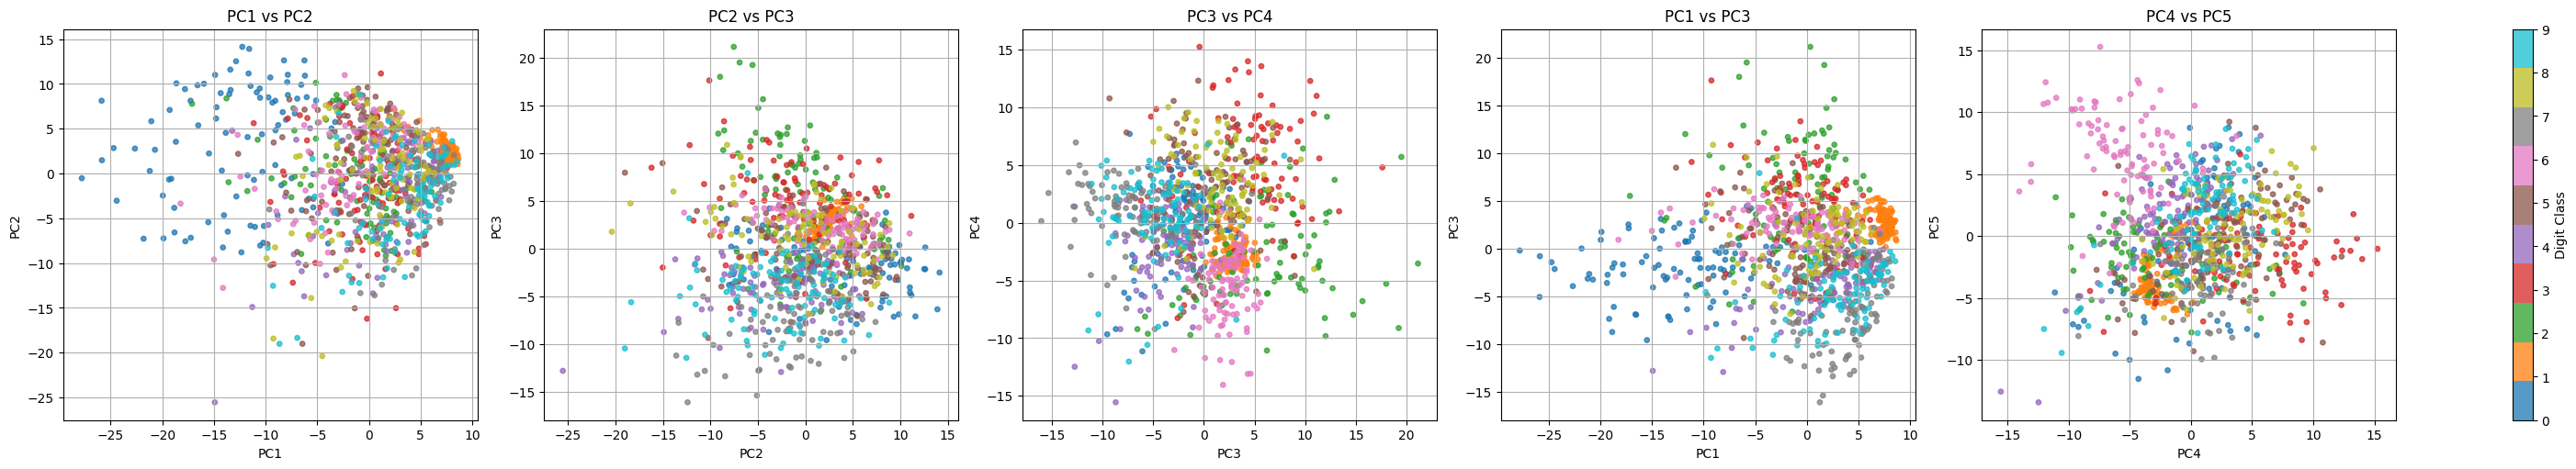

In [23]:
pc_pairs = [(1, 2), (2, 3), (3, 4), (1, 3), (4, 5)]

fig, axes = plt.subplots(1, 5, figsize=(28, 5), constrained_layout=True)

for ax, pair in zip(axes, pc_pairs):
    pc_x, pc_y = pair

    scatter = ax.scatter(
        X_pca[:, pc_x - 1],
        X_pca[:, pc_y - 1],
        c=y_balanced,
        cmap="tab10",
        alpha=0.75,
        s=15
    )

    ax.set_xlabel(f"PC{pc_x}")
    ax.set_ylabel(f"PC{pc_y}")
    ax.set_title(f"PC{pc_x} vs PC{pc_y}")
    ax.grid(True)

fig.colorbar(scatter, ax=axes, ticks=range(10), label="Digit Class")

plt.show()

These PCA scatter plots show that the MNIST digits have some meaningful structure in the principal component space, but the classes are not perfectly separated. This is expected because PCA is an unsupervised method: it chooses directions that maximize variance in the image data, not directions that directly maximize separation between digit labels.

In the PC1 vs PC2 plot, there is a visible overall spread in the data, with some classes occupying different regions. For example, one digit class appears more spread toward the far left of PC1, while several other classes cluster more densely on the right side. However, most colors overlap heavily near the center and right side of the plot. This means that the first two principal components capture important global variation in handwriting style and digit shape, but they are not sufficient to cleanly separate all digit classes.

The PC2 vs PC3 plot shows a slightly different organization of the data. Some classes form loose groups in certain regions, but there is still substantial overlap among many digits. This indicates that PC3 contains additional shape information not shown in PC1 vs PC2, but the separation is still limited.

In the PC3 vs PC4 plot, the points are more concentrated near the center, with several classes mixed together. Some colors appear more common in certain vertical or horizontal regions, suggesting that these components capture secondary patterns such as stroke thickness, curvature, slant, or loop structure. However, the overlap remains large.

The PC1 vs PC3 plot again shows that some classes stretch along PC1, while others are more concentrated. This projection reveals that PC1 is an important direction for broad image variation. Still, many digit classes share similar regions, especially around the central cluster. This suggests that different handwritten digits can have similar global pixel patterns when viewed through only two principal components.

The PC4 vs PC5 plot shows even more overlap, although there are still hints of structure. Since PC4 and PC5 explain less variance than the earlier components, they capture finer details rather than the largest sources of variation. These details may help distinguish some digit shapes, but by themselves they do not produce clear class separation.

Overall, the plots reveal that PCA captures meaningful low-dimensional structure in the MNIST dataset. Some digits form loose clusters or occupy characteristic regions, but there is no complete separation between all ten classes in any of the 2D projections. This happens because handwritten digits vary in many ways, and two principal components cannot represent all of the information needed to distinguish them. Digits with similar shapes, such as 3, 5, 8, and 9, tend to overlap more. Therefore, PCA is useful for visualization and dimensionality reduction, but it is not designed to be a perfect classifier by itself.

#### Interpretation
Each step of PCA is important because PCA is trying to find a new coordinate system that represents the original data using directions of maximum variation.

The covariance matrix matters because it measures how the original features vary together. In the MNIST dataset, each feature is a pixel. The covariance matrix tells us which pixels tend to increase or decrease together across images. For example, pixels near the center of the image may be correlated because many handwritten digits have strokes in the center. PCA uses this covariance structure to find patterns in the data rather than treating every pixel as completely independent.

The eigenvectors of the covariance matrix define the principal component directions. These are the new axes onto which the data is projected. The first eigenvector points in the direction where the data has the greatest variance. The second eigenvector points in the direction of the next greatest variance, while being orthogonal to the first, and so on. This allows PCA to rotate the original feature space into a new space where the most important variation appears first.

The eigenvalues tell us how much variance is captured by each corresponding eigenvector. A large eigenvalue means that its principal component explains a large amount of variation in the dataset. A small eigenvalue means that the component explains relatively little variation and may represent minor details or noise. Sorting eigenvalues from largest to smallest allows us to rank the principal components by importance.

The variance explained is important because it tells us how much information is preserved when we keep a certain number of principal components. The explained variance ratio shows the percentage of total variance captured by each component. The cumulative explained variance shows how much total variance is retained as more components are kept. This is what allows us to choose a reduced number of dimensions while still preserving most of the structure in the data. For example, if a certain number of components preserves 90% of the variance, then we can reduce the dimensionality significantly while keeping most of the important information.

A real-world application of PCA is image compression. Images often contain redundant information because neighboring pixels are usually correlated. PCA can represent images using fewer dimensions by keeping only the most important principal components. For example, instead of storing all 784 pixel values for each MNIST image, we can store a smaller number of PCA coefficients that preserve most of the visual structure. This reduces storage requirements and can also make later processing faster. PCA is also useful in face recognition, noise reduction, data visualization, and preprocessing high-dimensional data before applying machine learning models.